## 1.1. 가장 기본적인 LiDAR BA

`카메라 BA:` 2D Projection 오차를 최적화
$$
\min{
\sum_{i,j}{||u_{ij} - \pi(T_{i}X_{j})}||^{2}
}
$$

- $\pi$: Projection 함수
- $T_{i}$ : i번째 카메라의 Transform 행렬
- $X_{j}$: j번째 3D 좌표

`LiDAR BA`: LiDAR 관측값과 기하 제약을 만족하도록 pose와 map/landmark를 최적화
$$ P^{world}_{i,j} = T_{i} P_{i,j}^{LiDAR}$$
$$ \min_{{Ti​},{Xj​}} \sum_{ij}​ρ(r_{ij}^2​)​$$

---
## 1.2. Point-to-Plane BA

i번째 Frame에서 LiDAR to World: 
$$ P^{World}_{ij} = R_{i}P^{LiDAR}_{ij} + t_{i} $$

다른 LiDAR에서 찾은 대응 Surface의 평면:
$$ n^{T} P^{World}_{ij} + d = 0 $$

최종 residual은 다음과 같다.
$$
\boxed
{
r = n^{T}(R_{i}P^{LiDAR}_{ij} + t_{i}) + d
}
$$

즉,

> 변환한 LiDAR Point가 대응 평면에서 얼마나 멀리 떨어져 있는가? 를 최적화

LiDAR BA 목적함수는 아래와 같다.
$$
\boxed
{
\min_{T_{i}} \sum_{i,k} \rho(r^{2}_{ik})
}
$$
- $\rho$: Huber loss같은 robust loss이다.

---
## 1.3. LiDAR BA 구조 설계

`SE(3) perturbation`을 적용하면 다음과 같다:
- 최적화 문제에서 구하려는 것이 $\delta{\theta}$ 이기 때문에, $\theta$를 행렬 밖으로 뺌
$$ 
\delta{P^{World}_{ij}} = -[P^{World}_{ij}]_{\times} 
\delta{\theta} + \delta{t}
$$

따라서, 잔차 변화량은 다음과 같다:
$$ 
\begin{aligned}
\delta{r} 
&= n^{T}\delta{P^{World}_{ij}} \\
&= n^{T}(-[P^{World}_{ij}]_{\times} \delta{\theta} + \delta{t})
\end{aligned}
$$

잔차를 활용한 `Pose Jacobian`은 다음과 같다:
- 이게 Gauss-Newton 기본 식이다.(매개변수의 변화량을 탐색하는 방법)
$$
\boxed{
\begin{aligned}
J_{T}
&= \frac{\partial{r}}{\partial{
\begin{bmatrix} \delta{\theta} \\ \delta{t} \end{bmatrix}}} \\
&= 
\begin{bmatrix}
-n^{T}[P^{World}_{ij}]_{\times} & n^{T}
\end{bmatrix}
\end{aligned}
}
$$

Correspondance 쌍에 대해 잔차는 다음과 같다:
$$r_{ij} = n^{T}_{j} (q_{i} - q_{j})$$

그래서 source pose Jacobian은:

$$ \frac{\partial r}{\partial \xi_i} $$

destination pose Jacobian은:

$$ -\frac{\partial r}{\partial \xi_j} $$

---
## 1.4. 최적화

### Normal Equation

각 correspondence의 Jacobian을 쌓아 전체 Jacobian을 구성한다.

$$ J = \begin{bmatrix} J_1 \\ J_2 \\ \vdots \\ J_N \end{bmatrix}, \qquad r = \begin{bmatrix} r_1 \\ r_2 \\ \vdots \\ r_N \end{bmatrix} $$

Gauss-Newton의 Normal Equation은:

$$ \boxed{ H = J^T J } $$

$$ \boxed{ g = J^T r } $$

따라서 parameter update는:

$$ \boxed{ H\delta = -g } $$

---

### Pose 0 고정

전체 pose 중 첫 번째 pose를 기준 좌표계로 고정한다.

$$ \delta\xi_0 = 0 $$

따라서 나머지 pose에 해당하는 자유 변수만 사용한다.

$$ H_f = H[\text{free},\text{free}] $$ $$ g_f = g[\text{free}] $$

---

### Levenberg-Marquardt

Gauss-Newton의 Hessian에 damping term을 추가한다.

$$ \boxed{ H_{LM} = H_f + \lambda \operatorname{diag}(H_f) } $$

그리고 다음 선형 시스템을 풀어 pose update를 구한다.

$$ \boxed{ \delta\xi = -H_{LM}^{-1}g_f } $$

코드에서는 직접 역행렬을 계산하지 않고:

```python
delta_free = np.linalg.solve(H_lm, -g_free)
```

를 사용한다.

---

### Pose Update

구한 perturbation $\delta\xi_i$를 기존 pose에 적용한다.

$$ \xi_i \leftarrow \xi_i + \delta\xi_i $$

Rotation은 SO(3)의 exponential map을 이용하여:

$$ \boxed{ R_i^{new} = R_i \exp([\delta\theta_i]_\times) } $$

Translation은:

$$ \boxed{ t_i^{new} = t_i+\delta t_i } $$

즉, 전체 과정은 다음과 같다.

$$ \boxed{ r \rightarrow J \rightarrow H=J^TJ,\quad g=J^Tr \rightarrow H_{LM} \rightarrow \delta\xi \rightarrow T^{new} } $$

In [28]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree

np.set_printoptions(precision=3, suppress=True)
plt.rcParams["figure.dpi"] = 110

# 한글 폰트가 있으면 쓴다. 없으면 그림의 한글 라벨이 네모로 나온다.
from matplotlib import font_manager
_available = {f.name for f in font_manager.fontManager.ttflist}
for _name in ("Apple SD Gothic Neo", "AppleGothic", "NanumGothic",
              "Malgun Gothic", "Noto Sans CJK KR", "Arial Unicode MS"):
    if _name in _available:
        plt.rcParams["font.family"] = _name
        plt.rcParams["axes.unicode_minus"] = False
        plt.rcParams["mathtext.fontset"] = "dejavusans"   # 수식은 계속 DejaVu 로
        break

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 0. 샘플 데이터 생성하기

- 간단한 LiDAR 시뮬레이터를 추가한다.

In [29]:
import importlib
import lidar_simulator
importlib.reload(lidar_simulator)          # 커널을 재시작하지 않아도 최신 버전을 반영
from lidar_simulator import *

def perturb_poses(Rs, ts, seed=1, rot=0.05, trans=0.15):
    """참값을 흔들어 초기 추정을 만든다. 포즈 0 은 게이지라 그대로 둔다."""
    rng = np.random.default_rng(seed)
    Rs_perturbed = Rs.copy()
    ts_perturbed = ts.copy()
    for i in range(1, len(Rs)):
        Rs_perturbed[i] = so3_exp(rng.normal(scale=rot, size=3)) @ Rs[i]
        ts_perturbed[i] = ts[i] + rng.normal(scale=trans, size=3)
    return Rs_perturbed, ts_perturbed

spec = LidarSpec(channels=16, 
                azimuth_steps=400,
                elevation_min_deg=-15, 
                elevation_max_deg=15,
                max_range=30, 
                range_noise=0.05, 
                dropout=0.1)
objects = make_room_objects(True)
Rs, ts, scans = make_lidar_data(objects, 
                                n_pose=9, 
                                spec=spec,
                                seed=0, 
                                motion=True)

# 노이즈 포함시키기
R_init, t_init = perturb_poses(Rs, ts)

# 1. LiDAR 데이터 시각화

/var/folders/bq/dkjd1k_54ll178qpbs01rwbh0000gn/T/ipykernel_8342/2254513840.py:17: RuntimeWarning: divide by zero encountered in matmul
  P = P @ np.asarray(Rs[i]).T + np.asarray(ts[i])
/var/folders/bq/dkjd1k_54ll178qpbs01rwbh0000gn/T/ipykernel_8342/2254513840.py:17: RuntimeWarning: overflow encountered in matmul
  P = P @ np.asarray(Rs[i]).T + np.asarray(ts[i])
/var/folders/bq/dkjd1k_54ll178qpbs01rwbh0000gn/T/ipykernel_8342/2254513840.py:17: RuntimeWarning: invalid value encountered in matmul
  P = P @ np.asarray(Rs[i]).T + np.asarray(ts[i])


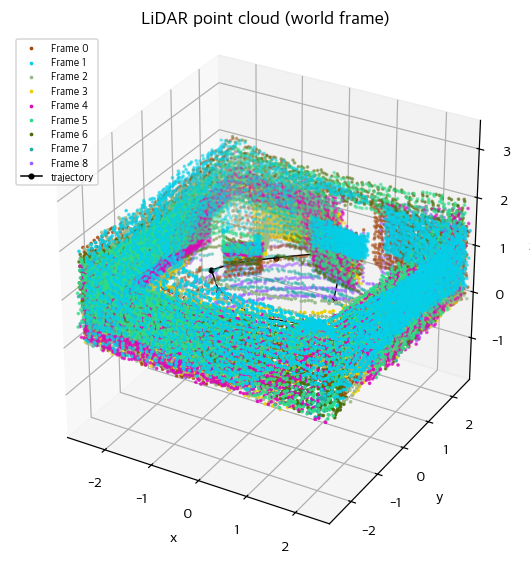

In [30]:
from typing import List, Optional, Sequence

def show_point_cloud(scans: List[LidarScan],
                     Rs: Optional[Sequence[np.ndarray]] = None,
                     ts: Optional[Sequence[np.ndarray]] = None,
                     frame: str = "world"):
    fig = plt.figure(figsize=(7, 6))
    ax = fig.add_subplot(111, projection="3d")
    rng = np.random.default_rng(0)          # 색을 고정해서 실행마다 같은 그림이 나오게 한다

    clouds = []
    for i, scan in enumerate(scans):
        P = scan.points
        if frame == "world":
            if Rs is None or ts is None:
                raise ValueError("frame='world' 에는 Rs, ts 가 필요하다")
            P = P @ np.asarray(Rs[i]).T + np.asarray(ts[i])
        clouds.append(P)
        ax.scatter(P[:, 0], P[:, 1], P[:, 2], s=2, color=rng.random(3), label=f"Frame {i}")

    if frame == "world" and ts is not None:
        T = np.asarray(ts)
        ax.plot(T[:, 0], T[:, 1], T[:, 2], "k.-", lw=1.0, ms=6, label="trajectory")

    # 축 비율을 1:1:1 로 맞춰야 방이 방처럼 보인다
    allp = np.vstack(clouds)
    center = allp.mean(axis=0)
    half = 0.5 * np.ptp(allp, axis=0).max()
    ax.set_xlim(center[0] - half, center[0] + half)
    ax.set_ylim(center[1] - half, center[1] + half)
    ax.set_zlim(center[2] - half, center[2] + half)
    ax.set_box_aspect((1, 1, 1))

    ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_zlabel("z")
    ax.set_title(f"LiDAR point cloud ({frame} frame)")
    ax.legend(fontsize=7, loc="upper left")
    plt.show()

show_point_cloud(scans, Rs, ts)

# 3. Bundle Adjustment

1. Normal, 포인트 별 Correspondance 찾기

In [31]:
# 1. Normal 추정하기

def estimate_normals(points, k=20):
    points = np.asarray(points, dtype=float)
    if len(points) < 2:
        return np.zeros_like(points)
    k = min(k, len(points) - 1)                     # 이웃이 모자라면 있는 만큼만

    tree = cKDTree(points)
    _, indices = tree.query(points, k=k + 1)        # 0 번은 자기 자신이라 버린다
    neighbours = points[indices[:, 1:]]             # (N, k, 3)

    centred = neighbours - neighbours.mean(axis=1, keepdims=True)
    covariance = np.einsum("nki,nkj->nij", centred, centred) / k
    _, eigenvectors = np.linalg.eigh(covariance)    # 쌓인 3x3 을 한 번에 푼다
    return eigenvectors[:, :, 0]

def scan_to_world(scans, Rs, ts):
    normals = [None] * len(scans)
    points = [None] * len(scans)
    for index, scan in enumerate(scans):
        point = np.dot(scan.points, Rs[index].T) + ts[index]
        points[index] = point
        normals[index] = estimate_normals(point)
    
    return points, normals

In [32]:
# 2. correspondence point 찾기
def find_correspondences(world_points_per_scan, max_distance=0.2):
    def core(source, target):
        tree = cKDTree(target)
        distance, index = tree.query(source, k=1, distance_upper_bound=max_distance)
        keep = distance < max_distance
        return np.nonzero(keep)[0], index[keep]

    correspondences = []

    for i in range(len(world_points_per_scan) - 1):
        source_indices, target_indices = core(
            world_points_per_scan[i], 
            world_points_per_scan[i + 1])
        correspondences.append((i, i + 1, source_indices, target_indices))

    return correspondences

In [33]:
def build_residuals(points, normals, correspondences):
    residuals = []

    for i, j, src_idx, dst_idx in correspondences:

        P = points[i][src_idx]
        Q = points[j][dst_idx]
        N = normals[j][dst_idx]

        residuals.append(np.sum(N * (P - Q), axis=1))

    return np.concatenate(residuals)

In [37]:
# 4. Make Jacobian
def make_jacobian(scans, normals, corr, R, t):
    number_of_pose = len(R)
    Jacobians = list()
    
    for source_idx, dest_idx, src_idx, dst_idx in corr:
        X_local = scans[source_idx].points[src_idx]
        n = normals[dest_idx][dst_idx]
        # (N, 3)
        X_world = np.dot(X_local, R[source_idx].T) + t[source_idx]
        # (N, 3, 3)
        P_world_skew = skew(X_world)
        # (N, 3)
        J_rot = -np.einsum("ni,nij->nj", n, P_world_skew)
        # (N, 6)
        J_pose = np.hstack([J_rot, n])
        # (3, 6 * Frames)
        J = np.zeros((len(X_local), 6 * number_of_pose))
        J[:, 6*source_idx: 6*source_idx+6] = J_pose
        J[:, 6*dest_idx: 6*dest_idx+6] = -J_pose
        Jacobians.append(J)
    
    return np.vstack(Jacobians)

In [38]:
def update_poses(R, t, delta):

    R_new = R.copy()
    t_new = t.copy()

    for i in range(1, len(R)):

        d = delta[6*(i-1):6*i]

        dtheta = d[:3]
        dt = d[3:]

        R_new[i] = so3_exp(dtheta) @ R[i]
        t_new[i] = so3_exp(dtheta) @ t[i] + dt

    return R_new, t_new

In [45]:
iteration = 5

R = R_init
t = t_init
number_of_frames = len(scans)
residual_history = list()

for it in range(iteration):
    # 1. Scan space to World space - (Number of Frame, N, 3)
    points, normals = scan_to_world(scans, R, t)
    # 2. Find correspondence - 
    # Source Frame Index, Target Frame Index, Base Point, Nearest Point
    # (int, int, (N), (N))
    corrs = find_correspondences(points, 0.2)
    # 3. Find Residual 
    residuals = build_residuals(points, normals, corrs)
    residual_history.append(residuals)
    # 4. Make Jcobians between Frames
    J = make_jacobian(scans, normals, corrs, R, t)
    # 5. Normal Equation
    H = np.dot(J.T, J)
    g = np.dot(J.T, residuals)
    # 6. Fixed Pose 0 - (6, 6 * Number of Frames)
    free = np.arange(6, 6 * number_of_frames)
    H_free = H[np.ix_(free, free)]
    g_free = g[free]
    # 7. LM
    lam = 1e-3
    H_lm = (H_free + lam * np.diag(np.diag(H_free)))
    delta_free = np.linalg.solve(H_lm, -g_free)
    R, t = update_poses(R, t, delta_free)

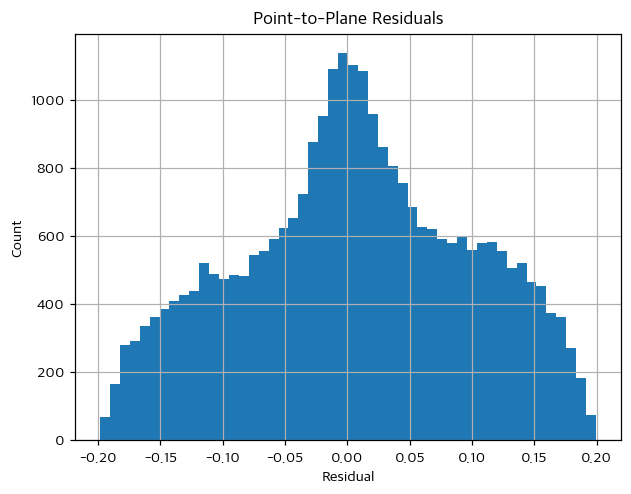

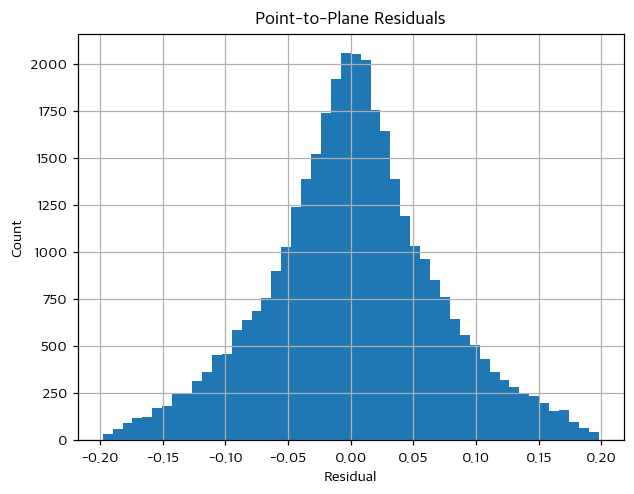

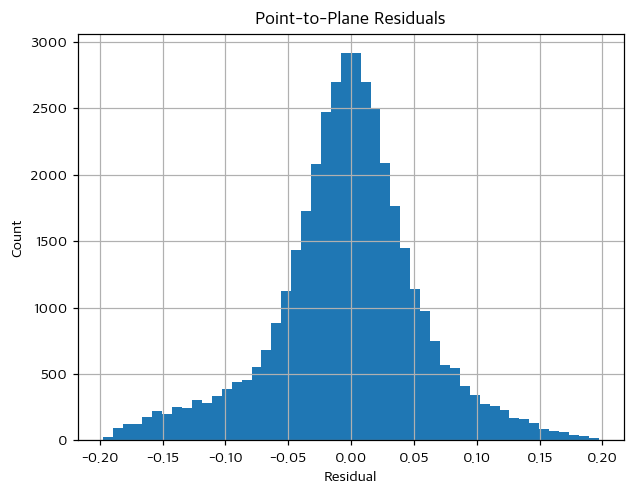

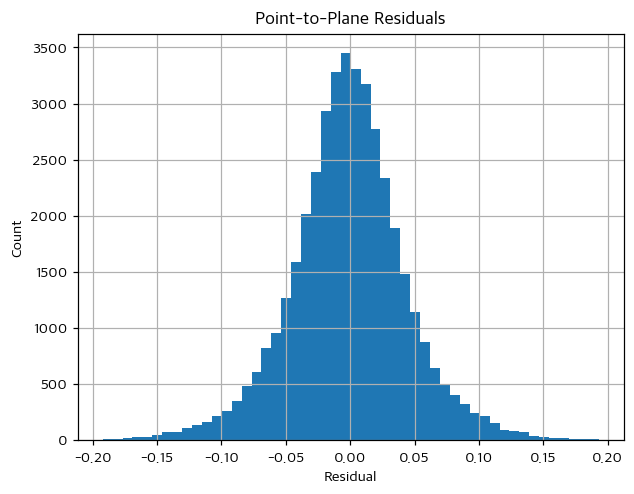

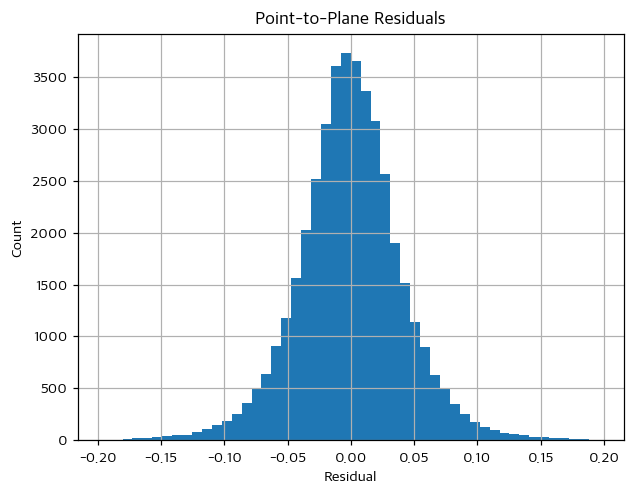

In [46]:
def show_residuals(residuals):
    residuals = np.asarray(residuals)

    plt.figure()
    plt.hist(residuals, bins=50)
    plt.xlabel("Residual")
    plt.ylabel("Count")
    plt.title("Point-to-Plane Residuals")
    plt.grid(True)
    plt.show()

for history in residual_history:
    show_residuals(history)

/var/folders/bq/dkjd1k_54ll178qpbs01rwbh0000gn/T/ipykernel_8342/2254513840.py:17: RuntimeWarning: divide by zero encountered in matmul
  P = P @ np.asarray(Rs[i]).T + np.asarray(ts[i])
/var/folders/bq/dkjd1k_54ll178qpbs01rwbh0000gn/T/ipykernel_8342/2254513840.py:17: RuntimeWarning: overflow encountered in matmul
  P = P @ np.asarray(Rs[i]).T + np.asarray(ts[i])
/var/folders/bq/dkjd1k_54ll178qpbs01rwbh0000gn/T/ipykernel_8342/2254513840.py:17: RuntimeWarning: invalid value encountered in matmul
  P = P @ np.asarray(Rs[i]).T + np.asarray(ts[i])


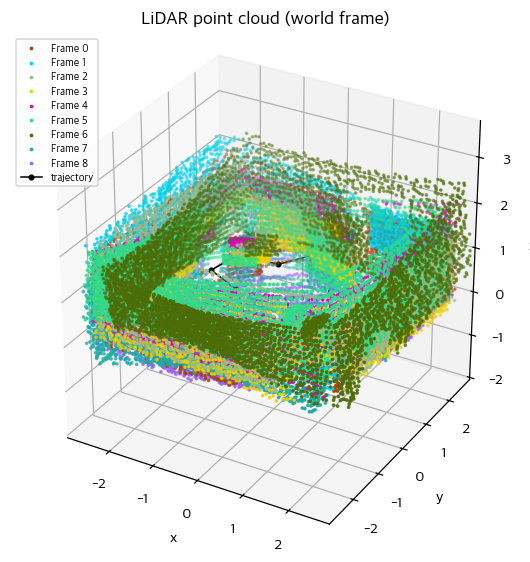

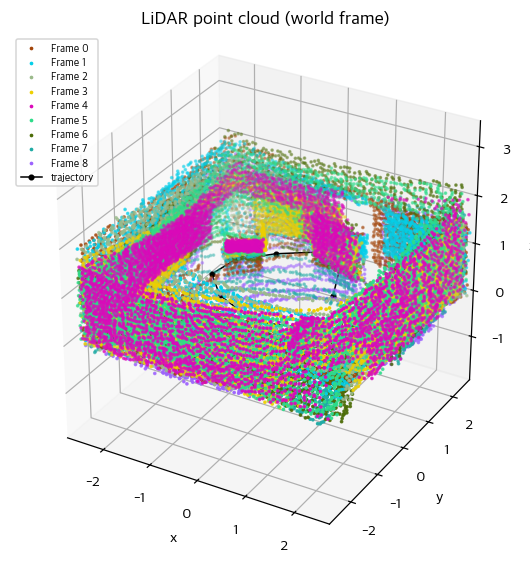

In [47]:
show_point_cloud(scans, R_init, t_init)
show_point_cloud(scans, R, t)